# Модуль 14. Policy gradient и современные методы

Ноутбук к [модулю 14](https://drobyshevdev.github.io/lemma/modules/14-policy-gradient/).

REINFORCE руками, база как критик, актор-критик и — главное — воспроизводимость: почему одна кривая обучения в RL ничего не значит и как проверять заявленное улучшение бутстрэпом из модуля 1. Только `numpy` и `matplotlib`.

**Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

def softmax(z):
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

MU = np.array([0.2, 0.85, 0.5, 0.35])   # средние награды действий; лучшее -- a2 (индекс 1)
BEST = int(MU.argmax())

## 1. REINFORCE на бандите

Политика — softmax над логитами. Каждый шаг: выбрать действие, получить шумную награду, сдвинуть логиты по $\nabla\log\pi\cdot(r-b)$. Действия, заплатившие выше базы, поднимаются.

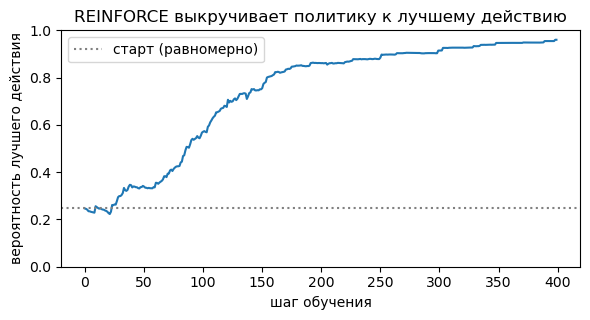

In [2]:
def reinforce(steps, seed, baseline=True, lr=0.14, sigma=0.3):
    g = np.random.default_rng(seed)
    theta = np.zeros(len(MU)); b = 0.0; prob_best = []
    for _ in range(steps):
        pi = softmax(theta)
        a = g.choice(len(MU), p=pi)
        r = MU[a] + g.normal(0, sigma)
        adv = r - (b if baseline else 0.0)
        theta += lr * adv * (np.eye(len(MU))[a] - pi)   # градиент softmax-политики
        b += 0.05 * (r - b)                             # база = скользящее ожидание награды
        prob_best.append(softmax(theta)[BEST])
    return np.array(prob_best)

fig, ax = plt.subplots(figsize=(6, 3.3))
ax.plot(reinforce(400, seed=0))
ax.axhline(1 / len(MU), ls=":", color="gray", label="старт (равномерно)")
ax.set_xlabel("шаг обучения"); ax.set_ylabel("вероятность лучшего действия")
ax.set_ylim(0, 1); ax.set_title("REINFORCE выкручивает политику к лучшему действию")
ax.legend(); plt.tight_layout(); plt.show()

Политика сама пришла к лучшему действию — не потому, что ей сказали, какое лучшее, а по наградам.

**Сломать.** Сблизьте награды (`MU = [0.5, 0.6, 0.55, 0.52]`) — сходимость станет медленной и шумной: близкие ценности при шумной награде трудно различить, ровно как в модуле 1.

## 2. База — это критик

В формуле стоит отдача, но из неё можно вычесть базу, не зависящую от действия: в среднем градиент не изменится, а разброс упадёт. Хорошая база — ожидаемая награда, то есть ценность. Сравним обучение с базой и без, усреднив по многим зёрнам.

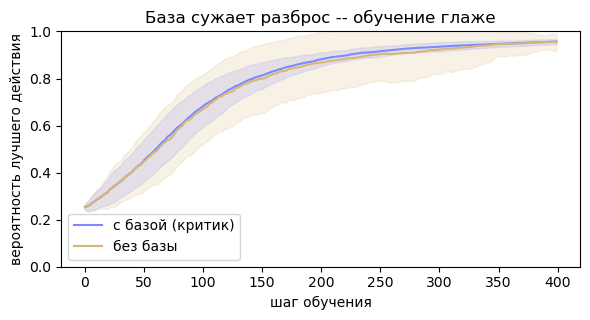

разброс на шаге 200 -- с базой: 0.029   без базы: 0.127


In [3]:
seeds = range(60)
with_b = np.array([reinforce(400, s, baseline=True) for s in seeds])
no_b = np.array([reinforce(400, s, baseline=False) for s in seeds])

fig, ax = plt.subplots(figsize=(6, 3.3))
for curves, name, col in [(with_b, "с базой (критик)", "#7b8aff"), (no_b, "без базы", "#d8b678")]:
    m, sd = curves.mean(0), curves.std(0)
    ax.plot(m, label=name, color=col)
    ax.fill_between(range(len(m)), m - sd, m + sd, color=col, alpha=0.18)
ax.set_xlabel("шаг обучения"); ax.set_ylabel("вероятность лучшего действия")
ax.set_ylim(0, 1); ax.set_title("База сужает разброс -- обучение глаже")
ax.legend(); plt.tight_layout(); plt.show()

print("разброс на шаге 200 -- с базой: %.3f   без базы: %.3f"
      % (with_b[:, 200].std(), no_b[:, 200].std()))

Полоса «с базой» уже: вычитание ожидаемого убирает из сигнала общий уровень награды и оставляет только преимущество действия. Это и есть критик, а разность $A = r - V$ — преимущество, оно же ошибка δ из модуля 13.

**Сломать.** Увеличьте шум награды (`sigma=0.8`) — обе полосы расширятся, но без базы разъедется сильнее: чем шумнее награда, тем важнее вычесть её ожидание.

## 3. Актор-критик на контекстном бандите

Настоящий критик — не одно число, а ценность на состояние. Два контекста, в каждом лучшее действие своё. Актор держит политику на контекст, критик — ценность на контекст; преимущество $A = r - V(c)$.

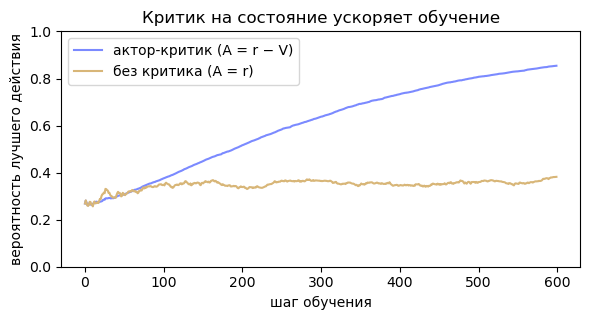

вероятность лучшего на шаге 300 -- критик: 0.64   без: 0.36


In [4]:
MU_CTX = np.array([[0.2, 0.85, 0.5, 0.35],
                   [0.8, 0.30, 0.4, 0.50]]) + 5.0   # общий уровень наград высок --
#                                                     именно там критик, вычитая его, важнее всего
BEST_CTX = MU_CTX.argmax(1)

def actor_critic(steps, seed, use_critic=True, lr=0.14, lrv=0.1, sigma=0.3):
    g = np.random.default_rng(seed)
    theta = np.zeros((2, 4)); V = np.zeros(2); perf = []
    for _ in range(steps):
        c = g.integers(2)
        pi = softmax(theta[c])
        a = g.choice(4, p=pi)
        r = MU_CTX[c, a] + g.normal(0, sigma)
        adv = r - (V[c] if use_critic else 0.0)
        theta[c] += lr * adv * (np.eye(4)[a] - pi)
        V[c] += lrv * (r - V[c])
        perf.append(np.mean([softmax(theta[k])[BEST_CTX[k]] for k in range(2)]))
    return np.array(perf)

seeds = range(40)
ac = np.array([actor_critic(600, s, use_critic=True) for s in seeds]).mean(0)
pg = np.array([actor_critic(600, s, use_critic=False) for s in seeds]).mean(0)

fig, ax = plt.subplots(figsize=(6, 3.3))
ax.plot(ac, label="актор-критик (A = r − V)", color="#7b8aff")
ax.plot(pg, label="без критика (A = r)", color="#d8b678")
ax.set_xlabel("шаг обучения"); ax.set_ylabel("вероятность лучшего действия")
ax.set_ylim(0, 1); ax.set_title("Критик на состояние ускоряет обучение")
ax.legend(); plt.tight_layout(); plt.show()
print("вероятность лучшего на шаге 300 -- критик: %.2f   без: %.2f" % (ac[300], pg[300]))

Критик, вычитая ценность каждого контекста, снимает разницу между контекстами и оставляет актору чистое преимущество действия. Дофаминовая δ из модуля 13 двигает сразу два обучения — актора и критика.

**Сломать.** Сделайте контексты одинаковыми (`MU_CTX[1] = MU_CTX[0]`) — преимущество критика почти исчезнет: снимать нечего, когда состояния не различаются.

## 4. Воспроизводимость: одна кривая ничего не значит

Прогоним один метод на двадцати зёрнах. Кривые расходятся веером — тот же алгоритм с другим зерном учится по-разному.

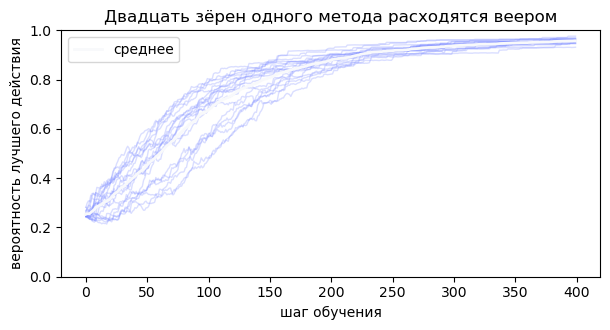

итог на прогон: мин 0.93, макс 0.98 -- одно число ничего не говорит


In [5]:
seeds = range(20)
runs = np.array([reinforce(400, s) for s in seeds])

fig, ax = plt.subplots(figsize=(6.2, 3.4))
for c in runs:
    ax.plot(c, color="#7b8aff", alpha=0.28, lw=1)
ax.plot(runs.mean(0), color="#f8f9fb", lw=2, label="среднее")
ax.set_xlabel("шаг обучения"); ax.set_ylabel("вероятность лучшего действия")
ax.set_ylim(0, 1); ax.set_title("Двадцать зёрен одного метода расходятся веером")
ax.legend(); plt.tight_layout(); plt.show()

finals = runs[:, -1]
print("итог на прогон: мин %.2f, макс %.2f -- одно число ничего не говорит" % (finals.min(), finals.max()))

Показать одну удачную кривую — соблазн из модуля 1, пункт «выбор зерна». Честно — сводить много зёрен устойчивой статистикой.

## 5. Честное сравнение методов

Две настройки learning rate как «метод» и «база». Сравниваем не по одному прогону, а по межквартильному среднему с бутстрэп-интервалом из модуля 1.

In [6]:
def iqm(x):
    x = np.sort(x); k = len(x) // 4
    return x[k:len(x) - k].mean()

def bootstrap_ci(vals, stat, n=5000, seed=0):
    g = np.random.default_rng(seed); vals = np.asarray(vals)
    draws = g.choice(vals, size=(n, len(vals)), replace=True)
    s = np.array([stat(row) for row in draws])
    return np.percentile(s, [2.5, 97.5])

def final_perf(lr, seeds):
    return np.array([reinforce(400, s, lr=lr)[-1] for s in seeds])

seeds = range(15)
A = final_perf(0.14, seeds)      # «метод»
B = final_perf(0.10, seeds)      # «база»
for name, x in [("метод lr=0.14", A), ("база  lr=0.10", B)]:
    lo, hi = bootstrap_ci(x, iqm)
    print("%s: IQM = %.3f, 95%% интервал [%.3f, %.3f]" % (name, iqm(x), lo, hi))

la, ha = bootstrap_ci(A, iqm); lb, hb = bootstrap_ci(B, iqm)
overlap = not (la > hb or lb > ha)
print("интервалы перекрываются:", overlap, "->",
      "разница не показана" if overlap else "разница пережила зёрна")

метод lr=0.14: IQM = 0.960, 95% интервал [0.955, 0.964]
база  lr=0.10: IQM = 0.936, 95% интервал [0.928, 0.943]
интервалы перекрываются: False -> разница пережила зёрна


Если интервалы перекрылись — правило из модуля 1: разница не показана, как бы ни хотелось объявить победу по средним. Ровно так обученную политику сравнивают с настроенной классической базой в [decisionrl](https://github.com/DrobyshevDev/decisionrl).

## Что дальше

В [модуле 15](https://drobyshevdev.github.io/lemma/programme/) у ошибки появляется цена в деньгах: запасы, ценообразование, очереди. И там же — когда обученная политика выигрывает у классики исследования операций, а когда классика уже оптимальна, и признать второе — часть той же дисциплины проверки.